In [ ]:
import numpy as np
from qiskit import  QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector

# Quantum error correction

Quantum error correction is a set of techniques used to protect quantum information from noise and unwanted interactions with the environment. This is necessary because qubits are extremely fragile: small errors can appear during computation, storage, or measurement, and these errors can destroy the quantum state being processed.

Unlike classical bits, qubits can suffer from different types of errors. A classical bit can mainly flip from $0$ to $1$ or from $1$ to $0$, but a qubit can also suffer changes in its phase. For this reason, quantum error correction must be able to detect and correct both bit-flip and phase-flip errors.

A **bit-flip error** is analogous to a classical error. It changes the state of a qubit as:

$$
|0\rangle \rightarrow |1\rangle
$$

and:

$$
|1\rangle \rightarrow |0\rangle
$$

This type of error is represented by the Pauli-$X$ gate.

A **phase-flip error** does not change the computational value of the qubit, but changes the relative phase between basis states. It acts as:

$$
|0\rangle \rightarrow |0\rangle
$$

and:

$$
|1\rangle \rightarrow -|1\rangle
$$

This type of error is represented by the Pauli-$Z$ gate.

The main idea of quantum error correction is to encode one logical qubit into several physical qubits. This redundancy allows us to detect where an error has occurred without directly measuring and destroying the quantum information. We will first study simple codes that correct only bit-flip and phase-flip errors, and then move towards more general and complete error correction schemes.

When working with quantum correction codes, we will use the following notation:

$$
[[n,k,d]]
$$
where:
- $n$: number of used physical qubits.
- $k$: number of encoded logical qubits.
- $d$: distance of the code.

In quantum codes, the distance is the minimum number of qubits that need to be affected by an error for the error to become undetectable. Therefore, a code with distance $d$ can detect up to $d-1$ errors and correct up to $\left\lfloor \frac{d-1}{2} \right\rfloor$ errors.

# Bit-flip

We will design the circuit using 3 qubits: the first one containing the original state and two auxiliary qubits on the $|0\rangle$ state. We will need two different stages. First, an encoding circuit introduces redundancy into the qubit we want to protect. Then, an error correction circuit detects and corrects possible errors. Let's assume that que initial state is:

$$
|\alpha \rangle = \alpha_0 |0\rangle + |\alpha_1 |1\rangle
$$

The encoding circuit will consist on two CNOT operations controlled by the first qubit and targets on each of the auxiliary qubits. That way, we will perform the transformation:

$$
(\alpha_0 |0\rangle + |\alpha_1 |1\rangle )\otimes |0\rangle \otimes |0\rangle \rightarrow \alpha_0 |000\rangle + \alpha_1 |111\rangle
$$

The error correction circuit will consist on two CNOT operations controlled by the first qubit and targets on each of the auxiliary qubits and a Toffoli gate targeting the first qubit. That way, given a arbitrary input $|x \rangle |y \rangle |z \rangle$, the circuit will perform the transformation:

$$
|x \rangle |y \rangle |z \rangle \xrightarrow{\text{CNOT gates}} |x \rangle |y \oplus x \rangle |z \oplus x \rangle \xrightarrow{\text{Toffoli gate}} |x \oplus (y \oplus x)\cdot (z \oplus x) \rangle |y \oplus x \rangle |z \oplus x \rangle
$$

Let's begin by analizing the states of the auxiliary qubits: their final state will only be $|1\rangle$ if and only if their original state was different from the first qubit's state. Measuring these qubits help us detect whether a bit flip has occurred.

Now, let's analyze the first register by expanding its expression:

$$
x \oplus (y \oplus x)\cdot (z \oplus x) = x \oplus (yz \oplus xy \oplus xz \oplus x^2) = xy \oplus xz \oplus yz
$$

Since the expression is symmetric for $x$, $y$ and $z$, this gives four possible cases:

| Case | Input state pattern | Expression $xy \oplus xz \oplus yz$ | 
|---|---|---:|
| All qubits are $0$ | $\|000\rangle$ | $0$ |
| Only one qubit is $1$ | $\|100\rangle$, $\|010\rangle$, $\|001\rangle$ | $0$ | 
| Two qubits are $1$ | $\|110\rangle$, $\|101\rangle$, $\|011\rangle$ | $1$ | 
| All qubits are $1$ | $\|111\rangle$ | $1$ | 

This shows that the correction circuit restores the first qubit according to the majority value of the three-qubit encoded state. Therefore, if at most one bit-flip error occurs, the original logical state can be recovered.

Let's now implement and test this circuit.

In [15]:
def bit_flip_circuit(initial_state: QuantumCircuit, bit_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a 3-qubit bit-flip error correction circuit for a 1-qubit initial state, applying X noise according to bit_flip_idx.
    """

    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    # Create registers
    state = QuantumRegister(1, "State")
    aux = QuantumRegister(2, "aux")
    qc = QuantumCircuit(state, aux)

    # Prepare the initial state
    qc.compose(initial_state, qubits=state, inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])

    qc.barrier()

    # Noise
    if len(bit_flip_idx) > 0:
        qc.x(bit_flip_idx)

    qc.barrier()

    # Error correction
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])
    qc.ccx(aux[0], aux[1], state[0])

    return qc


########################################
First qubit initial state:
########################################


<IPython.core.display.Latex object>

########################################
Case: No bit-flip noise
########################################
Final state:


<IPython.core.display.Latex object>

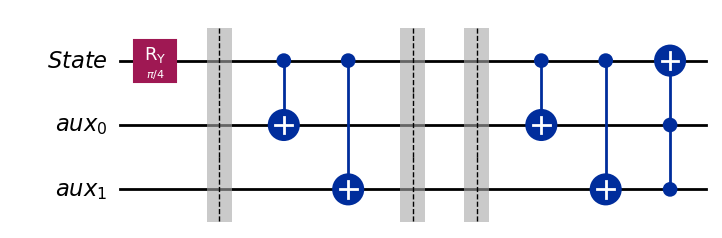

########################################
Case: Bit-flip noise on one qubit
########################################
Final state:


<IPython.core.display.Latex object>

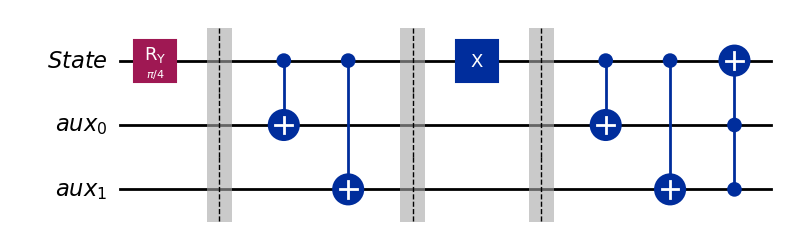

########################################
Case: Bit-flip noise on two qubits
########################################
Final state:


<IPython.core.display.Latex object>

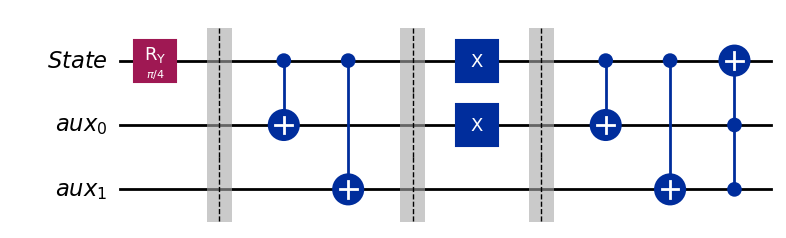

########################################
Case: Bit-flip noise on all three qubits
########################################
Final state:


<IPython.core.display.Latex object>

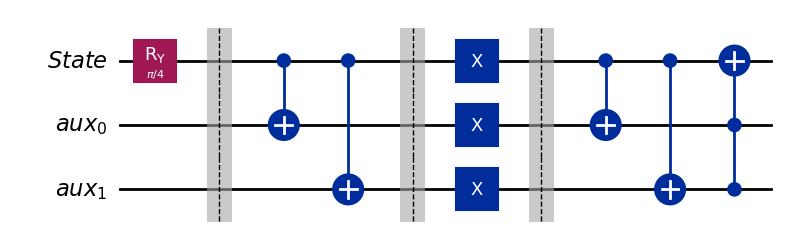

In [16]:
noise_cases = [
    [],  
    [0],   
    [0, 1],   
    [0, 1, 2],     
]

cases_description = [
    "No bit-flip noise",
    "Bit-flip noise on one qubit",
    "Bit-flip noise on two qubits",
    "Bit-flip noise on all three qubits"
]

assert len(noise_cases) == len(cases_description)

# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print(40 * "#")
print("First qubit initial state:")
print(40 * "#")
display(sv_init.draw("latex"))

# Test the bit-flip error correction circuit with different noise cases
for i in range(len(noise_cases)):
    qc = bit_flip_circuit(initial_state, noise_cases[i])
    sv = Statevector.from_instruction(qc)
    print(40 * "#")
    print("Case:", cases_description[i])
    print(40 * "#")
    print("Final state:")
    display(sv.draw("latex"))
    display(qc.draw("mpl"))
    

Let's analyze the four cases one by one. It is important to keep in mind Qiskit's ordering convention: in the statevector labels, the rightmost bit corresponds to the first qubit of the circuit.

- **First case:** no noise is applied. The original state is preserved in the first qubit and the auxiliary state is $|00\rangle$, which tells us that no error has occurred.

- **Second case:** one bit-flip error is applied. The circuit is able to correct it, so the original state is again preserved in the first qubit. The auxiliary qubits end in a non-zero syndrome state, indicating that an error was detected and corrected.

- **Third case:** two bit-flip errors are applied. In this case, the code can no longer recover the original state correctly, because the 3-qubit repetition code is only designed to correct a single bit-flip error. With two errors, the majority vote points to the wrong logical value.

- **Fourth case:** all three qubits are flipped. This produces a logical bit-flip of the encoded state. Since all qubits are flipped together, the auxiliary syndrome can look consistent, but the logical information has been changed. Therefore, this case cannot be corrected by the code.

Overall, the results show that the bit-flip code works as expected: it preserves the logical state when there is no error or a single bit-flip error, but it fails when two or more qubits are affected.

# Phase-flip

Previously, we said that bit-flip errors are represented by Pauli-$X$ gates and phase-flip errors are represented by Pauli-$Z$ gates. These two gates and related by the following identity:

$$
X = HZH
$$

We can easily prove it by taking their matrix expressions:

$$
HZH =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
1 & -1 \\
1 & 1
\end{pmatrix}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
=
\frac{1}{2}
\begin{pmatrix}
0 & 2 \\
2 & 0
\end{pmatrix}
=
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
= X
$$

This identity shows that a bit-flip error can be interpreted as a phase-flip error in the Hadamard basis. Therefore, we can correct phase-flip errors by changing basis with Hadamard gates, applying the same correction logic used for bit-flip errors, and then changing back to the original basis.

In [17]:
def phase_flip_circuit(initial_state: QuantumCircuit, phase_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a 3-qubit phase-flip error correction circuit for a 1-qubit initial state, applying Z noise according to phase_flip_idx.
    """
    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    

    # Create registers
    state = QuantumRegister(1, "State")
    aux = QuantumRegister(2, "aux")
    qc = QuantumCircuit(state, aux)

    # Prepare the initial state
    qc.compose(initial_state, qubits=state, inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])

    # Basis change
    qc.h(state[0])
    qc.h(aux)

    qc.barrier()

    # Noise
    if len(phase_flip_idx) > 0:
        qc.z(phase_flip_idx)

    qc.barrier()

    # Undo basis change
    qc.h(state[0])
    qc.h(aux)

    # Error correction
    qc.cx(state[0], aux[0])
    qc.cx(state[0], aux[1])
    qc.ccx(aux[0], aux[1], state[0])

    return qc


########################################
Initial state:
########################################


<IPython.core.display.Latex object>

########################################
Case: No phase-flip noise
########################################
Final state:


<IPython.core.display.Latex object>

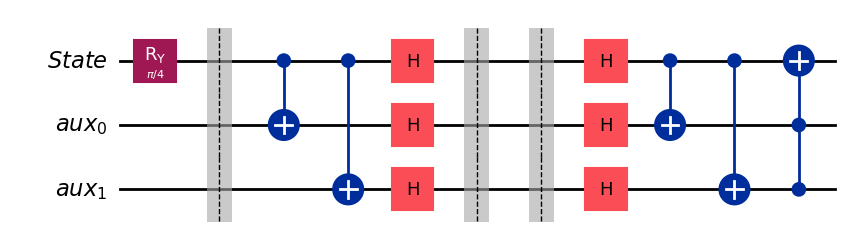

########################################
Case: Phase-flip noise on one qubit
########################################
Final state:


<IPython.core.display.Latex object>

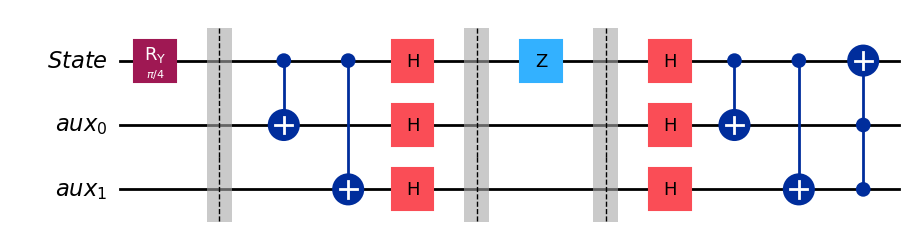

########################################
Case: Phase-flip noise on two qubits
########################################
Final state:


<IPython.core.display.Latex object>

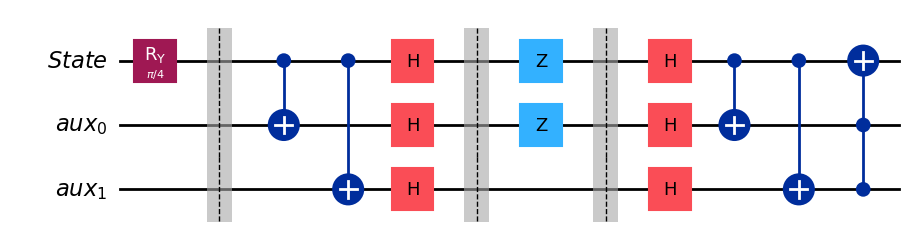

########################################
Case: Phase-flip noise on all three qubits
########################################
Final state:


<IPython.core.display.Latex object>

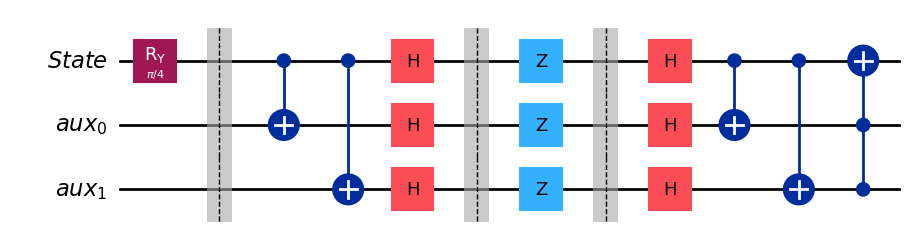

In [18]:
noise_cases = [
    [],  
    [0],   
    [0, 1],   
    [0, 1, 2],     
]

cases_description = [
    "No phase-flip noise",
    "Phase-flip noise on one qubit",
    "Phase-flip noise on two qubits",
    "Phase-flip noise on all three qubits"
]

assert len(noise_cases) == len(cases_description)

# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print(40 * "#")
print("Initial state:")
print(40 * "#")
display(sv_init.draw("latex"))

for i in range(len(noise_cases)):
    qc = phase_flip_circuit(initial_state, noise_cases[i])
    sv = Statevector.from_instruction(qc)
    print(40 * "#")
    print("Case:", cases_description[i])
    print(40 * "#")
    print("Final state:")
    display(sv.draw("latex"))
    display(qc.draw("mpl"))

The results are analogous to the bit-flip case. The phase-flip code correctly preserves the logical state when there is no error or only one phase-flip error, but it cannot correct cases where two or more qubits are affected.

# Using syndromes

In the previous implementation, error correction was performed coherently inside the circuit, using unitary gates to try to correct the effect of the error without explicitly extracting information about where the error occurred ,unless we do final measurements, which destroy the quantum information. Syndrome-based correction follows a different approach. Instead of measuring the encoded logical qubit directly, the circuit measures a set of auxiliary quantities called error syndromes. These syndromes are obtained by coupling the data qubits to ancilla qubits and measuring only the ancillas. The result does not reveal the logical state , but it provides enough information to identify the type and location of the error. This is why syndromes are used in quantum error correction: they allow errors to be diagnosed and corrected while preserving the encoded quantum information.

Let's start with the bit-flip circuit. We will use the same encoding circuit as before, so we only need to replace the correction stage with a syndrome-based correction circuit. This circuit uses two ancilla qubits and four CNOT gates. The first ancilla measures the parity between the first and second data qubits, while the second ancilla measures the parity between the second and third data qubits. After measuring the ancillas, we obtain a two-bit syndrome that indicates whether a bit-flip error occurred and, if so, on which qubit. Finally, we apply the corresponding correction depending on the measured syndrome:

| State | Syndrome | Correction |
|---|---|---|
| $\alpha_0\vert000\rangle + \alpha_1 \vert111\rangle$ | $00$ | $I \otimes I \otimes I$ |
| $\alpha_0\vert001\rangle + \alpha_1 \vert110\rangle$ | $01$ | $I \otimes I \otimes X$ |
| $\alpha_0\vert010\rangle + \alpha_1 \vert101\rangle$ | $11$ | $I \otimes X \otimes I$ |
| $\alpha_0\vert100\rangle + \alpha_1 \vert011\rangle$ | $10$ | $X \otimes I \otimes I$ |

In this way, the syndrome does not reveal the encoded logical state itself, but only the error pattern. This allows us to correct the bit-flip error without directly measuring or destroying the quantum information.

In [19]:
def syndrome_bit_flip_circuit(initial_state: QuantumCircuit, bit_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a syndrome measurement circuit for a 3-qubit bit-flip error correction code applied to a 1-qubit initial state, applying X noise according to bit_flip_idx.
    """

    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    # Create registers
    q = QuantumRegister(3, "q")
    anc = QuantumRegister(2, "ancilla")
    syn = ClassicalRegister(2, "meas")
    qc = QuantumCircuit(q, anc, syn)

    # Prepare the initial state
    qc.compose(initial_state, qubits=q[0], inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])

    qc.barrier()

    # Noise
    if len(bit_flip_idx) > 0:
        qc.x(bit_flip_idx)

    qc.barrier()

    # Syndormes
    qc.cx(q[0], anc[0])
    qc.cx(q[1], anc[0])
    qc.cx(q[1], anc[1])
    qc.cx(q[2], anc[1])
    qc.barrier()

    # Measurements
    qc.measure(anc, syn)

    qc.barrier()

    # Syndrome 10 -> X on q0
    with qc.if_test((syn[0], True)):
        with qc.if_test((syn[1], False)):
            qc.x(q[0])

    # Syndrome 11 -> X on q1
    with qc.if_test((syn[0], True)):
        with qc.if_test((syn[1], True)):
            qc.x(q[1])

    # Syndrome 01 -> X on q2
    with qc.if_test((syn[0], False)):
        with qc.if_test((syn[1], True)):
            qc.x(q[2])

    return qc

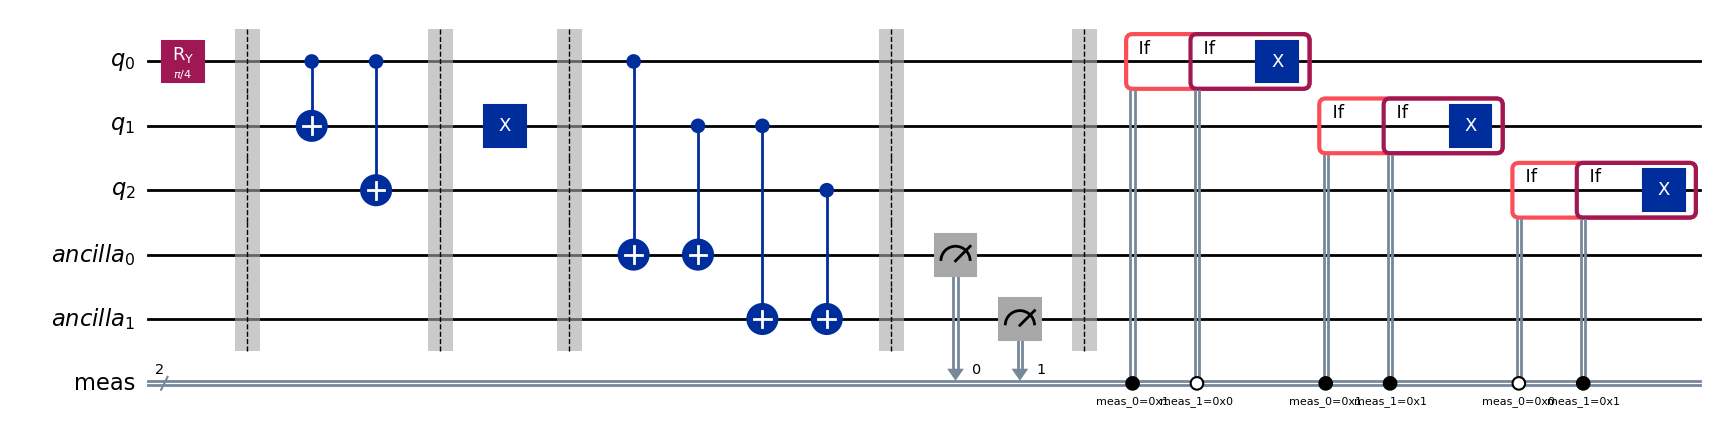

In [20]:
init = QuantumCircuit(1)
init.ry(np.pi /4, 0)
qc = syndrome_bit_flip_circuit(init, [1])
qc.draw("mpl")

Again, using the property $Z=HXH$, we can easily build an analogous version for the phase-flip noise. The syndrome measurements will now imply:

| State | Syndrome | Correction |
|---|---|---|
| $\alpha_0\vert000\rangle + \alpha_1 \vert111\rangle$ | $00$ | $I \otimes I \otimes I$ |
| $\alpha_0\vert001\rangle + \alpha_1 \vert110\rangle$ | $01$ | $I \otimes I \otimes Z$ |
| $\alpha_0\vert010\rangle + \alpha_1 \vert101\rangle$ | $11$ | $I \otimes Z \otimes I$ |
| $\alpha_0\vert100\rangle + \alpha_1 \vert011\rangle$ | $10$ | $Z \otimes I \otimes I$ |

In [21]:
def syndrome_phase_flip_circuit(initial_state: QuantumCircuit, phase_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds a syndrome measurement circuit for a 3-qubit phase-flip error correction code applied to a 1-qubit initial state, applying Z noise according to phase_flip_idx.
    """

    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    # Create registers
    q = QuantumRegister(3, "q")
    anc = QuantumRegister(2, "ancilla")
    syn = ClassicalRegister(2, "meas")
    qc = QuantumCircuit(q, anc, syn)

    # Prepare the initial state
    qc.compose(initial_state, qubits=q[0], inplace=True)

    qc.barrier()

    # Encoding: |alpha>|00> -> alpha_0|000> + alpha_1|111>
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])
    qc.h(q)

    qc.barrier()

    # Noise
    if len(phase_flip_idx) > 0:
        qc.z(phase_flip_idx)

    qc.barrier()

    # Syndormes
    qc.cx(q[0], anc[0])
    qc.cx(q[1], anc[0])
    qc.cx(q[1], anc[1])
    qc.cx(q[2], anc[1])
    qc.barrier()

    # Measurements in H basis
    qc.h(anc)
    qc.measure(anc, syn)

    qc.barrier()

    # Syndrome 10 -> X on q0
    with qc.if_test((syn[0], True)):
        with qc.if_test((syn[1], False)):
            qc.z(q[0])

    # Syndrome 11 -> X on q1
    with qc.if_test((syn[0], True)):
        with qc.if_test((syn[1], True)):
            qc.z(q[1])

    # Syndrome 01 -> X on q2
    with qc.if_test((syn[0], False)):
        with qc.if_test((syn[1], True)):
            qc.z(q[2])

    return qc

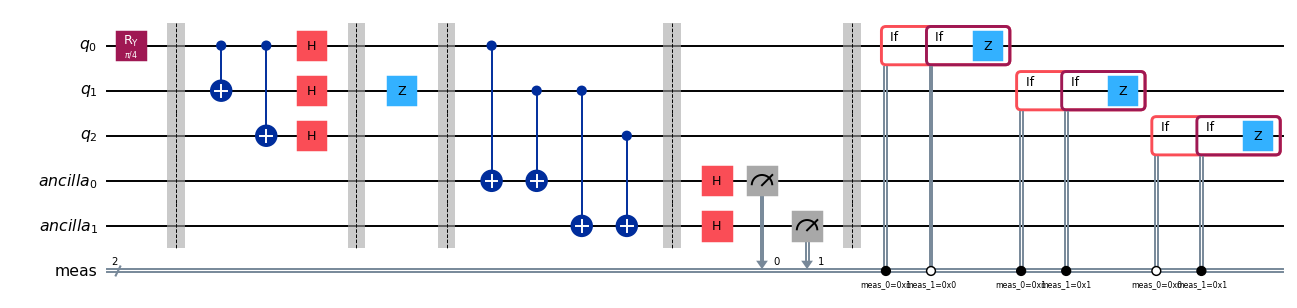

In [22]:
init = QuantumCircuit(1)
init.ry(np.pi /4, 0)
qc = syndrome_phase_flip_circuit(init, [1])
qc.draw("mpl", fold=40, scale=0.7)

# Shor code

Combining the bit-flip and phase-flip circuit we can build the Shor code: a quantum circuit capable of detecting both bit-flips and phase flips. The idea is quite intuitive: first, the logical qubit is protected against phase-flip errors by encoding it into three blocks. Then, each of these blocks is itself encoded using a three-qubit bit-flip code. In this sense, the code behaves like three phase-flip protected components, where each component is also protected against bit-flip errors.

This construction works because bit-flip and phase-flip errors can be addressed separately. Any general single-qubit error can be expressed as a linear combination of Pauli operators: $I$, $X$, $Z$, and $Y$. Here, $X$ represents a bit-flip error, $Z$ represents a phase-flip error, and $Y$ can be interpreted as a combination of both, since $Y = iXZ$. Therefore, by correcting both $X$ and $Z$ errors, the Shor code is also able to correct arbitrary single-qubit error

The Shor code is a $[[9,1,3]]$ quantum error correction code. Since its distance is $d=3$, it can correct any arbitrary single-qubit error and detect up to two arbitrary errors acting on physical qubits. However, if two errors occur, the code cannot always identify and correct them reliably.

For two-error patterns, correctability depends on the type of errors and on where they occur. Bit-flip errors are corrected inside each three-qubit block by majority voting. Therefore, the code can correct more than one $X$ error if there is at most one bit-flip error per block. For example, an error such as $X_0X_3$ can be corrected, because each $X$ acts on a different block. In contrast, an error such as $X_0X_1$ cannot be corrected reliably, because two bit flips in the same block break the majority-vote mechanism and may be misidentified as a single bit flip on the remaining qubit.

Phase-flip errors are treated at the block level. A single $Z$ error in one block is correctable, and two $Z$ errors inside the same block are harmless because they are equivalent to a stabilizer operation. For example, $Z_0Z_1$ does not change the logical information. However, two $Z$ errors in two different blocks, such as $Z_0Z_3$, are not generally correctable, because they make two blocks appear phase-flipped and the syndrome becomes ambiguous.

Mixed errors can also be corrected in some cases. For example, $X_2Z_7$ is correctable because the $X$ component affects only one qubit within its block, while the $Z$ component affects only one block at the phase-correction level. More generally, a two-error pattern is correctable when its bit-flip part does not introduce more than one $X$-type error in the same block, and its phase-flip part does not affect more than one block with an odd phase-flip parity.

Thus, although the Shor code is guaranteed to correct any single-qubit error, it can also correct some specific two-qubit error patterns due to its internal structure.

In [23]:
def shor_code(initial_state: QuantumCircuit, bit_flip_idx: list[int], phase_flip_idx: list[int]) -> QuantumCircuit:
    """
    Builds the Shor code circuit for a 1-qubit initial state, applying X anb Z noise according to bit_flip_idx and phase_flip_idx.
    """
    # Validate input
    if initial_state.num_qubits != 1:
        raise ValueError("initial_state must be a 1-qubit circuit.")
    
    qc = QuantumCircuit(9)

    # Prepare the initial state
    qc.compose(initial_state, qubits=[0], inplace=True)
    qc.barrier()

    # Encoding
    qc.cx(0, 3)
    qc.cx(0, 6)
    for qubit in [0, 3, 6]:
        qc.h(qubit)
        qc.cx(qubit, qubit + 1)
        qc.cx(qubit, qubit + 2)
    qc.barrier()

    # Noise
    if len(phase_flip_idx) > 0:
        qc.z(phase_flip_idx)
    if len(bit_flip_idx) > 0:
        qc.x(bit_flip_idx)
    qc.barrier()

    # Error correction
    for qubit in [0, 3, 6]:
        qc.cx(qubit, qubit + 1)
        qc.cx(qubit, qubit + 2)
        qc.ccx(qubit + 1, qubit + 2, qubit)
        qc.h(qubit)
    qc.cx(0, 3)
    qc.cx(0, 6)
    qc.ccx(6, 3, 0)

    return qc

Let's first visualize and then test the circuit for many different cases.

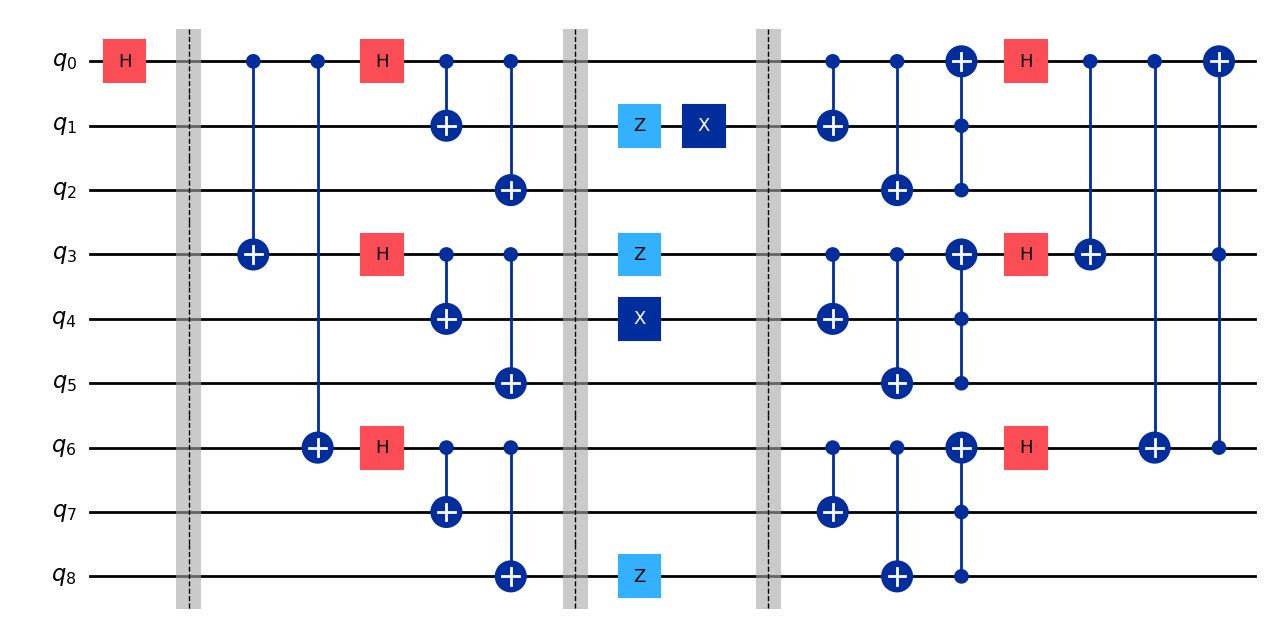

In [24]:
qc = QuantumCircuit(1)
qc.h(0)
shor_code(qc, [1, 4], [1, 3, 8]).draw("mpl")

In [25]:
noise_cases = [
    [[], []],  
    [[0], []],      
    [[0, 1], []],
    [[0, 4], []],   
    [[], [0]],  
    [[], [0, 1]],
    [[], [0, 4]], 
    [[0], [1]],
    [[0], [3]]
]

cases_description = [
    "No noise",
    "Bit-flip noise on one qubit",
    "Bit-flip noise on two qbits in the same block",
    "Bit-flip noise on two qbits in different same block",
    "Phase-flip noise on one qubit",
    "Phase-flip noise on two qbits in the same block",
    "Phase-flip noise on two qbits in different same block",
    "Phase-flip and bit-flip noise on two qbits in the same same block",
    "Phase-flip and bit-flip noise on two qbits in different same block"
]

assert len(noise_cases) == len(cases_description)

# Initial state preparation
initial_state = QuantumCircuit(1)
initial_state.ry(np.pi / 4, 0)
sv_init = Statevector.from_instruction(initial_state)
print(50 * "#")
print("Initial state:")
print(50 * "#")
display(sv_init.draw("latex"))

for i in range(len(noise_cases)):
    qc = shor_code(initial_state, noise_cases[i][0], noise_cases[i][1])
    sv = Statevector.from_instruction(qc)
    print(50 * "#")
    print("Case:", cases_description[i])
    print(50 * "#")
    print("Final state:")
    display(sv.draw("latex"))

##################################################
Initial state:
##################################################


<IPython.core.display.Latex object>

##################################################
Case: No noise
##################################################
Final state:


<IPython.core.display.Latex object>

##################################################
Case: Bit-flip noise on one qubit
##################################################
Final state:


...

<IPython.core.display.Latex object>

##################################################
Case: Phase-flip and bit-flip noise on two qbits in the same same block
##################################################
Final state:


<IPython.core.display.Latex object>

##################################################
Case: Phase-flip and bit-flip noise on two qbits in different same block
##################################################
Final state:


<IPython.core.display.Latex object>

These examples represent only a subset of the possible error combinations in the Shor code. Many other noise patterns can be tested easily by modifying the `noise_cases` list in the code. Overall, the observed behavior matches the expected theory: all arbitrary single-qubit errors are corrected, while some multi-qubit errors are also corrected depending on their structure. In particular, the code succeeds when the bit-flip components do not break the majority vote within a block and when the phase-flip components do not affect multiple blocks ambiguously. Cases that violate these conditions are not reliably correctable, as expected for a $[[9,1,3]]$ code.